<a href="https://colab.research.google.com/github/mrabdullah99/maize-nutrient-deficiency-detection/blob/main/train_leaf_gate_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -U tensorflow-datasets

In [ ]:
import tensorflow_datasets as tfds

print("Version:", tfds.__version__)
print("Location:", tfds.__file__)
print("Has load:", hasattr(tfds, "load"))
print("Has builder:", hasattr(tfds, "builder"))

Version: 4.9.10
Location: /usr/local/lib/python3.12/dist-packages/tensorflow_datasets/__init__.py
Has load: True
Has builder: True


In [ ]:
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf
import tensorflow_datasets as tfds

from sklearn.model_selection import train_test_split

In [ ]:
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!rm -rf /content/maize_dataset

!rm -f /content/maize_dataset.zip

!cp /content/drive/MyDrive/maize_dataset.zip /content/maize_dataset.zip

!unzip -q /content/maize_dataset.zip -d /content/maize_dataset

!rm /content/maize_dataset.zip

In [ ]:
root = "/content/maize_dataset/maize_dataset"

for split in os.listdir(root):

    split_path = os.path.join(root, split)

    if os.path.isdir(split_path):

        print(f"\n{split}")

        for cls in sorted(os.listdir(split_path)):

            cls_path = os.path.join(split_path, cls)

            if os.path.isdir(cls_path):

                print(f"{cls:<25} {len(os.listdir(cls_path))}")


train
ALL Present               1176
ALLAB                     1944
KAB                       3441
NAB                       1228
PAB                       2970
ZNAB                      2036

test
ALL Present               294
ALLAB                     486
KAB                       860
NAB                       307
PAB                       2376
ZNAB                      509


In [ ]:
import os

BASE_DIR = "/content/binary_maize_dataset"

splits = ["train", "validation", "test"]
classes = ["maize", "non_maize"]

for split in splits:
    for cls in classes:
        os.makedirs(
            os.path.join(BASE_DIR, split, cls),
            exist_ok=True
        )

print("Folder structure created.")

Folder structure created.


In [ ]:
from sklearn.model_selection import train_test_split
import os

SOURCE_ROOT = "/content/maize_dataset/maize_dataset"

all_images = []

for split in ["train", "test"]:

    split_path = os.path.join(SOURCE_ROOT, split)

    for cls in os.listdir(split_path):

        cls_path = os.path.join(split_path, cls)

        if not os.path.isdir(cls_path):
            continue

        for img in os.listdir(cls_path):

            all_images.append(
                (
                    os.path.join(cls_path, img),
                    cls
                )
            )

print("Total maize images:", len(all_images))

Total maize images: 17627


In [ ]:
train_imgs, temp_imgs = train_test_split(
    all_images,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

val_imgs, test_imgs = train_test_split(
    temp_imgs,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

print("Train:", len(train_imgs))
print("Validation:", len(val_imgs))
print("Test:", len(test_imgs))

Train: 12338
Validation: 2644
Test: 2645


In [ ]:
import shutil

def copy_images(image_list, split):

    destination = os.path.join(
        BASE_DIR,
        split,
        "maize"
    )

    for index, (image_path, class_name) in enumerate(image_list):

        extension = os.path.splitext(image_path)[1]

        filename = f"{class_name}_{index:05d}{extension}"

        shutil.copy(
            image_path,
            os.path.join(destination, filename)
        )


copy_images(train_imgs, "train")
copy_images(val_imgs, "validation")
copy_images(test_imgs, "test")

print("Maize dataset created successfully!")

Maize dataset created successfully!


In [ ]:
for split in splits:

    folder = os.path.join(
        BASE_DIR,
        split,
        "maize"
    )

    print(split)

    print("Images:", len(os.listdir(folder)))

    print("-"*40)

train
Images: 12338
----------------------------------------
validation
Images: 2644
----------------------------------------
test
Images: 2645
----------------------------------------


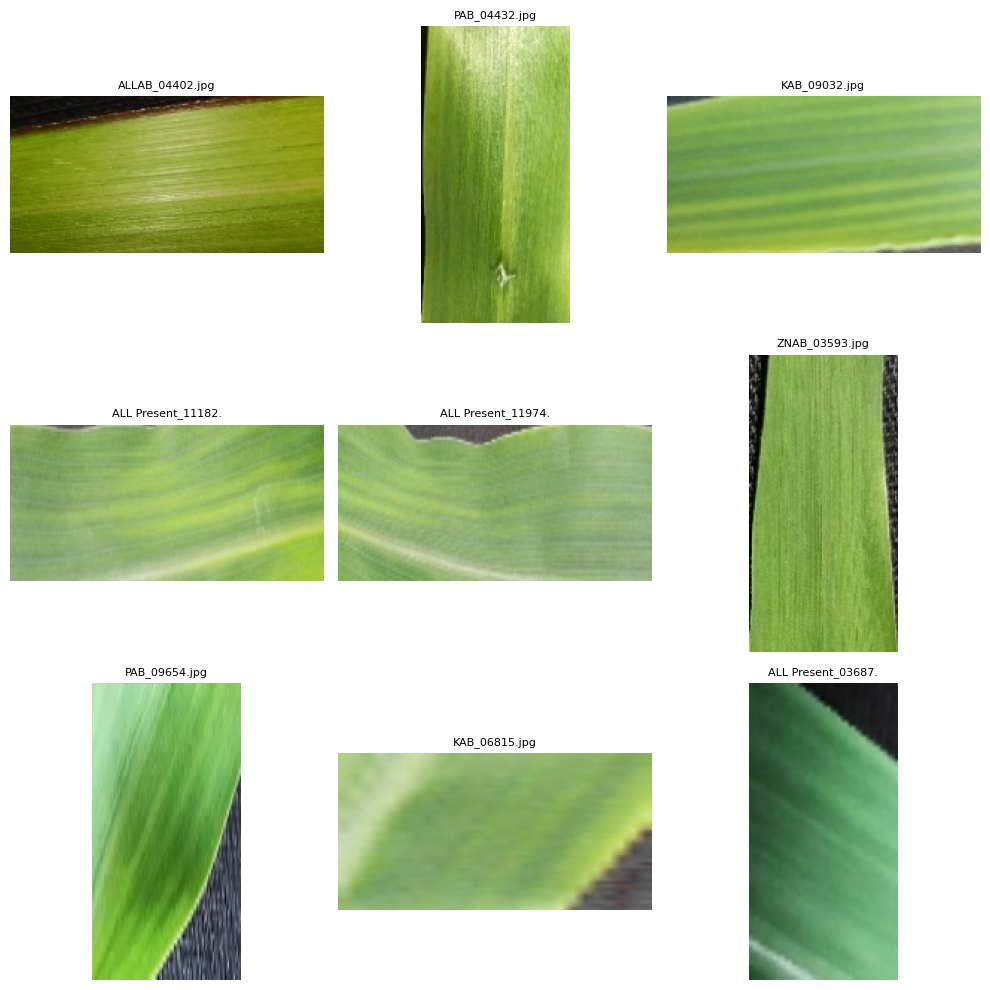

In [ ]:
import matplotlib.pyplot as plt
import random
from PIL import Image

folder = os.path.join(BASE_DIR, "train", "maize")

images = random.sample(os.listdir(folder), 9)

plt.figure(figsize=(10,10))

for i, img_name in enumerate(images):

    plt.subplot(3,3,i+1)

    img = Image.open(os.path.join(folder, img_name))

    plt.imshow(img)

    plt.title(img_name[:18], fontsize=8)

    plt.axis("off")

plt.tight_layout()

plt.show()

In [ ]:
import tensorflow_datasets as tfds

print("Downloading Caltech-101...")
caltech_builder = tfds.builder("caltech101")
caltech_builder.download_and_prepare()

print("Downloading Oxford-IIIT Pet...")
pet_builder = tfds.builder("oxford_iiit_pet")
pet_builder.download_and_prepare()

print("Datasets downloaded successfully!")

print("Downloading Food-101...")

food_builder = tfds.builder("food101")
food_builder.download_and_prepare()

print("Food-101 downloaded successfully!")

Datasets downloaded successfully!


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.23CP78_2.0.0/food101-train.tfrecord-[0-9][0-9][0-9][0-9…

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.23CP78_2.0.0/food101-validation.tfrecord-[0-9][0-9][0-9…

Dataset food101 downloaded and prepared to /root/tensorflow_datasets/food101/2.0.0. Subsequent calls will reuse this data.
Food-101 downloaded successfully!


In [ ]:
import tensorflow_datasets as tfds

caltech_ds = tfds.load(
    "caltech101",
    split="train",
    shuffle_files=True
)

pet_ds = tfds.load(
    "oxford_iiit_pet",
    split="train",
    shuffle_files=True
)

food_ds = tfds.load(
    "food101",
    split="train",
    shuffle_files=True
)

print("Food-101 loaded.")

print("Datasets loaded successfully!")

Food-101 loaded.
Datasets loaded successfully!


In [ ]:
builder = tfds.builder("caltech101")

builder.download_and_prepare()

info = builder.info

labels = info.features["label"].names

for i, label in enumerate(labels):
    print(i, label)

0 accordion
1 airplanes
2 anchor
3 ant
4 background_google
5 barrel
6 bass
7 beaver
8 binocular
9 bonsai
10 brain
11 brontosaurus
12 buddha
13 butterfly
14 camera
15 cannon
16 car_side
17 ceiling_fan
18 cellphone
19 chair
20 chandelier
21 cougar_body
22 cougar_face
23 crab
24 crayfish
25 crocodile
26 crocodile_head
27 cup
28 dalmatian
29 dollar_bill
30 dolphin
31 dragonfly
32 electric_guitar
33 elephant
34 emu
35 euphonium
36 ewer
37 faces
38 faces_easy
39 ferry
40 flamingo
41 flamingo_head
42 garfield
43 gerenuk
44 gramophone
45 grand_piano
46 hawksbill
47 headphone
48 hedgehog
49 helicopter
50 ibis
51 inline_skate
52 joshua_tree
53 kangaroo
54 ketch
55 lamp
56 laptop
57 leopards
58 llama
59 lobster
60 lotus
61 mandolin
62 mayfly
63 menorah
64 metronome
65 minaret
66 motorbikes
67 nautilus
68 octopus
69 okapi
70 pagoda
71 panda
72 pigeon
73 pizza
74 platypus
75 pyramid
76 revolver
77 rhino
78 rooster
79 saxophone
80 schooner
81 scissors
82 scorpion
83 sea_horse
84 snoopy
85 soccer_bal

In [ ]:
import os
import shutil

POOL_DIR = "/content/non_maize_pool"

if os.path.exists(POOL_DIR):
    shutil.rmtree(POOL_DIR)

os.makedirs(POOL_DIR, exist_ok=True)

print("Temporary pool created.")

Temporary pool created.


In [ ]:
import tensorflow_datasets as tfds
from PIL import Image

EXCLUDE = {
    "bonsai",
    "lotus",
    "sunflower",
    "water_lilly",
    "joshua_tree"
}

builder = tfds.builder("caltech101")
info = builder.info

label_names = info.features["label"].names

caltech = tfds.load(
    "caltech101",
    split="train",
    shuffle_files=True
)

count = 0

for sample in tfds.as_numpy(caltech):

    label = label_names[sample["label"]]

    if label in EXCLUDE:
        continue

    image = Image.fromarray(sample["image"])

    image = image.convert("RGB")

    image = image.resize((224,224))

    image.save(
        os.path.join(
            POOL_DIR,
            f"caltech_{count:06d}.jpg"
        )
    )

    count += 1

print("Caltech images:", count)

Caltech images: 2910


In [ ]:
pet = tfds.load(
    "oxford_iiit_pet",
    split="train",
    shuffle_files=True
)

for sample in tfds.as_numpy(pet):

    image = Image.fromarray(sample["image"])

    image = image.convert("RGB")

    image = image.resize((224,224))

    image.save(
        os.path.join(
            POOL_DIR,
            f"pet_{count:06d}.jpg"
        )
    )

    count += 1

print("Total after pets:", count)

Total after pets: 6590


In [ ]:
food = tfds.load(
    "food101",
    split="train",
    shuffle_files=True
)

for sample in tfds.as_numpy(food):

    image = Image.fromarray(sample["image"])

    image = image.convert("RGB")

    image = image.resize((224,224))

    image.save(
        os.path.join(
            POOL_DIR,
            f"food_{count:06d}.jpg"
        )
    )

    count += 1

print("Total images in pool:", count)

Total images in pool: 82340


In [ ]:
import random

all_images = os.listdir(POOL_DIR)

random.seed(42)
random.shuffle(all_images)

print("Total non-maize images:", len(all_images))

Total non-maize images: 82340


In [ ]:
train_count = 12338
val_count = 2644
test_count = 2645

train_files = all_images[:train_count]

val_files = all_images[
    train_count:
    train_count + val_count
]

test_files = all_images[
    train_count + val_count:
    train_count + val_count + test_count
]

print(len(train_files))
print(len(val_files))
print(len(test_files))

12338
2644
2645


In [ ]:
import shutil

def copy_split(file_list, split):

    destination = os.path.join(
        BASE_DIR,
        split,
        "non_maize"
    )

    os.makedirs(destination, exist_ok=True)

    for file in file_list:

        shutil.copy(
            os.path.join(POOL_DIR, file),
            os.path.join(destination, file)
        )


copy_split(train_files, "train")
copy_split(val_files, "validation")
copy_split(test_files, "test")

print("Binary dataset completed!")

Binary dataset completed!


In [ ]:
for split in ["train", "validation", "test"]:

    maize = len(
        os.listdir(
            os.path.join(BASE_DIR, split, "maize")
        )
    )

    non_maize = len(
        os.listdir(
            os.path.join(BASE_DIR, split, "non_maize")
        )
    )

    print(f"\n{split}")

    print("Maize     :", maize)

    print("Non-Maize :", non_maize)


train
Maize     : 12338
Non-Maize : 12338

validation
Maize     : 2644
Non-Maize : 2644

test
Maize     : 2645
Non-Maize : 2645


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil

print("Creating ZIP archive...")

shutil.make_archive(
    "/content/binary_maize_dataset_v1",
    "zip",
    "/content/binary_maize_dataset"
)

print("ZIP created!")

Creating ZIP archive...
ZIP created!


In [ ]:
import shutil

shutil.copy(
    "/content/binary_maize_dataset_v1.zip",
    "/content/drive/MyDrive/"
)

print("ZIP copied to Google Drive!")

ZIP copied to Google Drive!


In [ ]:
import os

print(os.path.exists("/content/binary_maize_dataset_v1.zip"))
print(os.listdir("/content")[:20])

True
['.config', 'non_maize_pool', 'binary_maize_dataset_v1.zip', 'binary_maize_dataset', 'maize_dataset', 'drive', 'sample_data']


In [ ]:
import os

for f in os.listdir("/content/drive/MyDrive"):
    if "binary" in f.lower():
        print(f)

binary_maize_dataset_v1.zip
binary_maize_dataset


In [ ]:
from google.colab import drive
drive.flush_and_unmount()
print("Drive unmounted and synced successfully!")

Drive unmounted and synced successfully!


In [ ]:
!cp "/content/drive/MyDrive/binary_maize_dataset_v1.zip" /content/

!unzip -q /content/binary_maize_dataset_v1.zip -d /content/

print("Dataset restored!")

cp: cannot stat '/content/drive/MyDrive/binary_maize_dataset_v1.zip': No such file or directory
Dataset restored!


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import layers, models

BASE_DIR = "/content/binary_maize_dataset"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    f"{BASE_DIR}/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    f"{BASE_DIR}/validation",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    f"{BASE_DIR}/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
)

print("Class order:", train_ds.class_names)  # ['maize', 'non_maize'] -> 0=maize, 1=non_maize

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.12),
])

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)

base_model = EfficientNetB0(include_top=False, weights="imagenet", input_shape=(224, 224, 3))
base_model.trainable = False
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Found 24676 files belonging to 2 classes.
Found 5288 files belonging to 2 classes.
Found 5290 files belonging to 2 classes.
Class order: ['maize', 'non_maize']
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
# Phase 1: train the head only
history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
)

Epoch 1/10
772/772 ━━━━━━━━━━━━━━━━━━━━ 108s 114ms/step - accuracy: 0.9918 - loss: 0.0335 - val_accuracy: 0.9983 - val_loss: 0.0083
Epoch 2/10
772/772 ━━━━━━━━━━━━━━━━━━━━ 85s 110ms/step - accuracy: 0.9994 - loss: 0.0045 - val_accuracy: 0.9989 - val_loss: 0.0046
Epoch 3/10
772/772 ━━━━━━━━━━━━━━━━━━━━ 75s 97ms/step - accuracy: 0.9998 - loss: 0.0024 - val_accuracy: 0.9992 - val_loss: 0.0032
Epoch 4/10
772/772 ━━━━━━━━━━━━━━━━━━━━ 76s 98ms/step - accuracy: 0.9998 - loss: 0.0017 - val_accuracy: 0.9996 - val_loss: 0.0024
Epoch 5/10
772/772 ━━━━━━━━━━━━━━━━━━━━ 77s 99ms/step - accuracy: 0.9999 - loss: 0.0011 - val_accuracy: 0.9996 - val_loss: 0.0021
Epoch 6/10
772/772 ━━━━━━━━━━━━━━━━━━━━ 77s 99ms/step - accuracy: 0.9999 - loss: 9.0292e-04 - val_accuracy: 0.9996 - val_loss: 0.0016
Epoch 7/10
772/772 ━━━━━━━━━━━━━━━━━━━━ 77s 99ms/step - accuracy: 0.9998 - loss: 6.2799e-04 - val_accuracy: 0.9996 - val_loss: 0.0015
Epoch 8/10
772/772 ━━━━━━━━━━━━━━━━━━━━ 76s 99ms/step - accuracy: 0.9999 - loss

KeyboardInterrupt: 

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test accuracy: {test_acc:.4f}")

166/166 ━━━━━━━━━━━━━━━━━━━━ 13s 80ms/step - accuracy: 1.0000 - loss: 3.9570e-04
Test accuracy: 1.0000


In [ ]:
model.save("/content/leaf_gate_model.keras")

import shutil
shutil.copy("/content/leaf_gate_model.keras", "/content/drive/MyDrive/leaf_gate_model.keras")
print("Model saved to Google Drive.")

Model saved to Google Drive.
